In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.chrome.options import Options
from flask import Flask, render_template,request
from datetime import date,datetime
import pyodbc,time,os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

chrome_options = Options()

chrome_options.add_argument("--mute-audio")
chrome_options.add_argument('blink-settings=imagesEnabled=false')
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options)
ftpath=r"C:\Users\h7236\OneDrive\桌面\f_templates"
app = Flask(__name__, template_folder=ftpath)
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    'charset="utf8";'
    )

font_path = r'C:\Windows\Fonts\kaiu.ttf'
plt.rcParams['font.sans-serif'] = ['DFKai-SB']
plt.rcParams['axes.unicode_minus'] = False
months = mdates.MonthLocator()
days = mdates.DayLocator()
timeFmt = mdates.DateFormatter('%m')

def driverfind(x):
    nn=0
    while(True):
        try:
            x1=driver.find_element(By.XPATH,x)
            return x1
        except:
            if nn!=0 and nn%20==0:
                driver.refresh()
                print('def ref')
            time.sleep(0.2)
            #print('def nn',nn)
            nn+=1

def driverfinds(x):
    try:
        x1=driver.find_elements(By.XPATH,x)
        return x1
    except:
        time.sleep(0.2)

def get_ldate(x):
    driver.get(f'{x}/about')
    a='''
        DROP TABLE IF EXISTS bdata;
        CREATE TABLE bdata (
            link_name NVARCHAR(300),
            link NVARCHAR(max),
        )
    '''
    conn.execute(a)
    conn.commit()
    time.sleep(1)
    try:
        x1=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a')
        x2=[j.get_attribute('href') for j in x1]
        x4=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a/yt-formatted-string')
        x5=[i2.text for i2 in x4]
    except:
        time.sleep(0.2)
    #print(len(x2))
    x3=int(len(x2)) 
    #print(x4)
    #print(x5)
    #print(x1)
    #print(x2)

    #print(x3)
    for i in range(0,x3):
        a = f'''INSERT INTO bdata (link_name,link) VALUES
                (?,'{x2[i]}')
        '''
        conn.execute(a,x5[i])
        conn.commit()

def get_cadate(x):
    driver.get(f'{x}/about')
    a='''
        DROP TABLE IF EXISTS adata;
        CREATE TABLE adata (
            cdate NVARCHAR(300),
            videos_number NVARCHAR(300),
            watchs_number NVARCHAR(300),
            location NVARCHAR(300),
        )
    '''#introduction NVARCHAR(300),
    conn.execute(a)
    conn.commit()

    aa=driverfind('//*[@id="right-column"]/yt-formatted-string[2]/span[2]')
    aa=f'加入日期：{aa.text}'

    zz=driverfind('//*[@id="videos-count"]/span[1]')
    yy=(f'影片數量：{zz.text}部')
    print(yy)

    
    ss=driverfind('//*[@id="right-column"]/yt-formatted-string[3]')
    tt=ss.text
    print(tt)

    ee=driverfind('//*[@id="details-container"]/table/tbody/tr[2]/td[2]/yt-formatted-string')
    ee=ee.text
    if ee=='':
        ee='不公開'
    ee=f'位置：{ee}'

    '''
    jj=driverfind('//*[@id="description-container"]').text
    print('---------------------------------------------------------------')
    print(jj)
    print('---------------------------------------------------------------')
    ii='<br>'.join(jj.split('\n'))
    print('---------------------------------------------------------------')
    print(ii)
    print('---------------------------------------------------------------')  
    if ii=='':
      #  ii.append('沒有簡介')
        ii=('沒有簡介')
    print(ii)
    print(jj)
    '''
    global ii
    jj=driverfind('//*[@id="description-container"]').text
    if jj=='':
        ii='無'
    else:
        jj=jj.split('\n')
        ii=jj[1:len(jj)]

    a = f'''INSERT INTO adata (cdate,videos_number,watchs_number,location) VALUES
            ('{aa}','{yy}','{tt}','{ee}')
        '''
    #,introduction ,'{ii}'
    conn.execute(a)
    conn.commit()
    
def get_time():
    ti=datetime.now()
    print('時間:',ti.hour,ti.minute,ti.second)
def get_cdata(x):
    a='''
        DROP TABLE IF EXISTS cdata;
        CREATE TABLE cdata (
            cheadsrc NVARCHAR(300),
            cname NVARCHAR(100),
            csub NVARCHAR(100),
            curl NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    def channels(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        #img = driver.find_elements(By.XPATH, '//*[@id="img"]')
        img = driverfinds('//*[@id="img"]')
        uptimes = 10 
        times = 0
        actions = ActionChains(driver)
        while times < uptimes:
            actions.send_keys(Keys.PAGE_DOWN)
            actions.perform()
            times += 1
            src = [i.get_attribute('src') for i in img]
            #img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
            img_element = driverfind('//*[@id="img"]')
            img_src = img_element.get_attribute('src')
            if img_src is None:
                break
        return src

    def names(x):
        #container = driver.find_elements(By.XPATH, '//*[@id="text"]')
        container = driverfinds('//*[@id="text"]')
        nam = [j.text for j in container]
        return nam

    def num(x):
        #num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
        num1 = driverfinds('//*[@id="video-count"]')
        num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
        return num2

    def web(x):
        #web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
        web1=driverfinds('//*[@id="avatar-section"]/a')
        web2=[l.get_attribute('href') for l in web1]
        return web2
    
    a1=channels(x)
    b1=names(x)
    c1=num(x)
    d1=web(x)

    t1=driverfinds('//*[@id="title"]')
    tt1=[]
    for i in t1:
        print(i.text)
        if i.text!='':
            tt1.append(i.text)
    e1=len(tt1)
    print('e1',e1)
    l=min(len(a1),len(b1),len(c1),len(d1))
    if l>16:
        l=16
    for i in range(e1,l):#('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
        a = f'''INSERT INTO cdata (cheadsrc,cname,csub,curl) VALUES
                ('{a1[i]}', ?, '{c1[i]}','{d1[i]}')
        '''
        conn.execute(a,b1[i])
        conn.commit() 

def get_tdate(x):
    driver.get(f'{x}/videos')

    a='''
        DROP TABLE IF EXISTS tdata;
        CREATE TABLE tdata (
            videos NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    '''
    while(True):
        try:
            aa=driver.find_element(By.XPATH,'//*[@id="videos-count"]/span[1]')
            break
        except:
            time.sleep(0.2)
    '''
    aa=driverfind('//*[@id="videos-count"]/span[1]')
    cc=int(aa.text)
    dd=round(cc/3)
    uptimes =int(dd)
    times = 0
    actions = ActionChains(driver)
    while times < uptimes:
        actions.send_keys(Keys.PAGE_DOWN)
        actions.perform()
        times += 1
        #img_element = driver.find_element(By.XPATH, '//*[@id="video-title-link"]')
        img_element = driverfind('//*[@id="video-title-link"]')
        img_src = img_element.get_attribute('href')
        if img_src is None:
            break
    #po1=driver.find_elements(By.XPATH,'//*[@id="video-title-link"]')
    po1=driverfinds('//*[@id="video-title-link"]')
    po2 = [j.get_attribute('href') for j in po1]
    print('lenpo2',len(po2))
    for i in range(len(po2)):
        a = f'''INSERT INTO tdata (videos) VALUES
                ('{po2[i]}')
        '''
        conn.execute(a)
        conn.commit()

def get_vdata(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        title nvarchar(100),
        url nvarchar(100)
    )'''#messages int,
    conn.execute(a)
    conn.commit() 
    for url in urls:
        get_time()
        url=url[0]
        #print(url)
        driver.get(url)
        time.sleep(1.2)
        '''
        while(True):
            try:
                a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
                break
            except:
                time.sleep(0.2)
        '''
        a=driverfind('//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        elif a.text=='喜歡':
            likes=0
        else:
            likes=int(a.text)
        '''
        while(True):
            try:
                driver.find_element(By.XPATH,'//*[@id="expand"]').click()
                break
            except:
                time.sleep(0.2)
        '''
        driverfind('//*[@id="expand"]').click()
        time.sleep(0.3)

        #b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        b=driverfind('//*[@id="info"]/span[1]')
        b=b.text
        #print(b[len(b)-6:len(b)])
        if b[len(b)-5:len(b)]=='觀眾等待中':
            watchs=0
        else:
            watchs=int(''.join((b[5:len(b)-1]).split(',')))

        #c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        c=driverfind('//*[@id="info"]/span[3]')
        t=c.text
        if t[0:5]=='首播日期：':
            t=t[5:len(t)]
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
        #e=driver.find_element(By.XPATH,'//*[@id="title"]/h1/yt-formatted-string')
        e=driverfind('//*[@id="title"]/h1/yt-formatted-string')
        title=e.text

        print(f'{likes},{watchs},{year},{month},{day},{title}')#{messages}
        a=f'''insert into vdata (url, likes, watchs, year, month, day, title) values
                ('{url}',{likes},{watchs},{year},{month},{day},?)
        '''#,{messages}
        conn.execute(a,title)
        conn.commit() 

 

@app.route('/')
def index():
    return render_template('index.html')
@app.route('/submit1', methods=['POST'])
def submit1():
    channel=request.values['channel']
    driver.get(f'https://m.youtube.com/results?search_query={channel}&sp=EgIQAg%253D%253D')
    time.sleep(2)
    #container = driver.find_element(By.XPATH, '//*[@id="text"]')
    container = driverfind('//*[@id="text"]')
    #print('container',container.text)
    if container.text=='':
        return render_template('f1.html')
    else:
        get_cdata(channel)
        a = "SELECT * FROM cdata"
        results = conn.execute(a)
        data = results.fetchall()
        return render_template('s1.html',**locals())


@app.route('/submit4', methods=['POST'])
def submit4():
    channel_url=request.values['channel_url']
    time.sleep(2)
    t=0
    
    try:
        driver.get(channel_url)
        time.sleep(2)
    except:
        t=1
    #print('container',container.text)
    if t==1:
        t=0
        return render_template('f2.html')
    else:
        csubs = driver.find_element(By.XPATH,'//*[@id="subscriber-count"]')
        csubs=csubs.text
        cimg=driverfind('//*[@id="img"]').get_attribute('src')
        cname=driverfind('//*[@id="text"]').text
        data=[(cimg,cname,csubs,channel_url)]
        return render_template('s1.html',**locals())

@app.route('/submit3', methods=['POST'])
def submit3():
    
    channel_url=request.values['channel_url']
    img_src=request.values['img_src']
    channel_name=request.values['channel_name']
    subs=request.values['subs']

    get_ldate(channel_url)
    get_cadate(channel_url)

    a = "SELECT * FROM adata"
    r = conn.execute(a)
    cd = r.fetchall()
    cd=cd[0]

    a = "SELECT * FROM bdata"
    r = conn.execute(a)
    ahref = r.fetchall()
    if ahref==[]:
        ahref='無'

    introduction=ii
    return render_template('s2.html',**locals())

@app.route('/submit2', methods=['POST'])
def submit2():
    
    channel_url=request.values['channel_url']
    img_src=request.values['img_src']
    channel_name=request.values['channel_name']
    subs=request.values['subs']

    #get_ldate(channel_url)
    #get_cadate(channel_url)

    a = "SELECT * FROM adata"
    r = conn.execute(a)
    cd = r.fetchall()
    cd=cd[0]

    a = "SELECT * FROM bdata"
    r = conn.execute(a)
    ahref = r.fetchall()
    if ahref==[]:
        ahref='無'

    introduction=ii
    print('introduction',introduction)

    print('time1')
    get_time()
    get_tdate(channel_url)
    a = "SELECT * FROM tdata"
    result1 = conn.execute(a)
    videous = result1.fetchall()
    get_vdata(videous)
    a = "SELECT * FROM vdata"
    result2 = conn.execute(a)
    videos = result2.fetchall()
    #print(videos)
    #print(videos[0][2],videos[len(videos)-1][2])
    #print(range(int(videos[0][2]),int(videos[len(videos)-1][2]+1)))
    ll=[]
    print('range',videos[len(videos)-1][2],videos[0][2]+1)
    for i in range(videos[len(videos)-1][2],videos[0][2]+1):#videos[0][2]+1
        print(i)
        l=[]
        for j in videos:
            if j[2]==i:
                l.append(j)
        ll.append(l)
    n1=1
    #print('n1n1',n1)
    print('ll',ll)
    while(True):
        #if os.path.exists(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}'):
        if os.path.exists(fr'{ftpath}\static\img{n1}'):
            n1+=1
            #print('n1',n1)
        else:
            #os.mkdir(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}')
            os.mkdir(fr'{ftpath}\static\img{n1}')
            #print('aaaaaaaa')
            break
    nn=0
    #print('n1',nn)
    pathl=[]
    for l in ll:
        dates=[]
        likes=[]
        watchs=[]
        for j in l:
            #print(j[2],j[3],j[4])
            dates.append(date(j[2],j[3],j[4]))
            likes.append(j[0])
            watchs.append(j[1])
        #print(l)
        if l==[]:
            continue
        #font_path = r'C:\Windows\Fonts\kaiu.ttf'
        #plt.rcParams['font.sans-serif'] = ['DFKai-SB']
        #plt.rcParams['axes.unicode_minus'] = False

        print('dates',dates)
        print('likes',likes)
        print('watch',watchs)

        months = mdates.MonthLocator()
        days = mdates.DayLocator()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,likes,'r-*',label='喜歡數')
        plt.legend()
        #print('lllllllllll',l)
        plt.title(f"{l[0][2]}喜歡數折線圖", fontsize=20)
        plt.xlabel('日期',fontsize=14)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        #plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.savefig(fr"{ftpath}\static\img{n1}\a{nn}.png")
        plt.show()

        fig, ax = plt.subplots(figsize=(7,4))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,watchs,'y-*',label='觀看數')
        plt.legend()
        plt.title(f"{l[0][2]}觀看數折線圖", fontsize=20)
        plt.xlabel('日期',fontsize=14)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        #plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.savefig(fr"{ftpath}\static\img{n1}\a{nn}.png")
        plt.show()
    n1=f'img{n1}'
    #print('pathl',pathl)
    #print('n1',n1)
    #driver.close()
    return render_template('ff.html',**locals())

app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


In [ ]:
def get_vdata(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        title nvarchar(100),
        url nvarchar(100)
    )'''#messages int,
    conn.execute(a)
    conn.commit() 
    for url in urls:
        get_time()
        url=url[0]
        #print(url)
        driver.get(url)
        time.sleep(1.2)
        '''
        while(True):
            try:
                a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
                break
            except:
                time.sleep(0.2)
        '''
        a=driverfind('//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        elif a.text=='喜歡':
            likes=0
        else:
            likes=int(a.text)
        '''
        while(True):
            try:
                driver.find_element(By.XPATH,'//*[@id="expand"]').click()
                break
            except:
                time.sleep(0.2)
        '''
        driverfind('//*[@id="expand"]').click()
        time.sleep(0.3)

        #b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        b=driverfind('//*[@id="info"]/span[1]')
        b=b.text
        #print(b[len(b)-6:len(b)])
        if b[len(b)-5:len(b)]=='觀眾等待中':
            watchs=0
        else:
            watchs=int(''.join((b[5:len(b)-1]).split(',')))

        #c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        c=driverfind('//*[@id="info"]/span[3]')
        t=c.text
        if t[0:5]=='首播日期：':
            t=t[5:len(t)]
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
        #e=driver.find_element(By.XPATH,'//*[@id="title"]/h1/yt-formatted-string')
        e=driverfind('//*[@id="title"]/h1/yt-formatted-string')
        title=e.text

        print(f'{likes},{watchs},{year},{month},{day},{title}')#{messages}
        a=f'''insert into vdata (url, likes, watchs, year, month, day, title) values
                ('{url}',{likes},{watchs},{year},{month},{day},?)
        '''#,{messages}
        conn.execute(a,title)
        conn.commit() 
get_vdata([('https://www.youtube.com/watch?v=uRd135xhw1g&ab_channel=Joeman')])

In [8]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from flask import Flask, render_template,request
from selenium.webdriver.common.action_chains import ActionChains
from datetime import date,datetime
import pyodbc,time,os
from selenium.webdriver.chrome.options import Options
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

chrome_options = Options()
chrome_options.add_argument("--memory-model=high")
chrome_options.add_argument("--mute-audio")
print(chrome_options.arguments)
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options)
ftpath=r"C:\Users\h7236\OneDrive\桌面\f_templates"#f_tempiates_path
app = Flask(__name__, template_folder=ftpath)
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    'charset="utf8";'
    )
f_tempiates_path=''

font_path = r'C:\Windows\Fonts\kaiu.ttf'
plt.rcParams['font.sans-serif'] = ['DFKai-SB']
plt.rcParams['axes.unicode_minus'] = False
months = mdates.MonthLocator()
days = mdates.DayLocator()
timeFmt = mdates.DateFormatter('%m')

def driverfind(x):
    nn=0
    while(True):
        try:
            x1=driver.find_element(By.XPATH,x)
            return x1
        except:
            if nn!=0 and nn%20==0:
                driver.refresh()
                print('def ref')
            time.sleep(0.2)
            print('def nn',nn)
            nn+=1
def driver1find(x,d):
    nn=0
    while(True):
        try:
            x1=d.find_element(By.XPATH,x)
            return x1
        except:
            if nn!=0 and nn%20==0:
                d.refresh()
                print('def ref')
            time.sleep(0.2)
            print('def nn',nn)
            nn+=1
def driverfinds(x):
    try:
        x1=driver.find_elements(By.XPATH,x)
        return x1
    except:
        time.sleep(0.2)
def driver1finds(x,d):
    try:
        x1=d.find_elements(By.XPATH,x)
        return x1
    except:
        time.sleep(0.2)
def get_ldate(x):
    driver.get(f'{x}/about')
    a='''
        DROP TABLE IF EXISTS bdata;
        CREATE TABLE bdata (
            link_name NVARCHAR(300),
            link NVARCHAR(max),
        )
    '''
    conn.execute(a)
    conn.commit()
    time.sleep(1)
    try:
        x1=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a')
        x2=[j.get_attribute('href') for j in x1]
        x4=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a/yt-formatted-string')
        x5=[i2.text for i2 in x4]
    except:
        time.sleep(0.2)
    #print(len(x2))
    x3=int(len(x2)) 
    #print(x4)
    #print(x5)
    #print(x1)
    #print(x2)

    #print(x3)
    for i in range(0,x3):
        a = f'''INSERT INTO bdata (link_name,link) VALUES
                ('{x5[i]}','{x2[i]}')
        '''
        conn.execute(a)
        conn.commit()

def get_cadate(x):
    driver.get(f'{x}/about')
    a='''
        DROP TABLE IF EXISTS adata;
        CREATE TABLE adata (
            cdate NVARCHAR(300),
            videos_number NVARCHAR(300),
            watchs_number NVARCHAR(300),
            location NVARCHAR(300),
        )
    '''#introduction NVARCHAR(300),
    conn.execute(a)
    conn.commit()

    aa=driverfind('//*[@id="right-column"]/yt-formatted-string[2]/span[2]')
    aa=f'加入日期：{aa.text}'

    zz=driverfind('//*[@id="videos-count"]/span[1]')
    yy=(f'影片數量：{zz.text}部')
    print(yy)

    
    ss=driverfind('//*[@id="right-column"]/yt-formatted-string[3]')
    tt=ss.text
    print(tt)

    ee=driverfind('//*[@id="details-container"]/table/tbody/tr[2]/td[2]/yt-formatted-string')
    ee=ee.text
    if ee=='':
        ee='不公開'
    ee=f'位置：{ee}'

    '''
    jj=driverfind('//*[@id="description-container"]').text
    print('---------------------------------------------------------------')
    print(jj)
    print('---------------------------------------------------------------')
    ii='<br>'.join(jj.split('\n'))
    print('---------------------------------------------------------------')
    print(ii)
    print('---------------------------------------------------------------')  
    if ii=='':
      #  ii.append('沒有簡介')
        ii=('沒有簡介')
    print(ii)
    print(jj)
    '''
    global ii
    jj=driverfind('//*[@id="description-container"]').text
    if jj=='':
        ii='無'
    else:
        jj=jj.split('\n')
        ii=jj[1:len(jj)]

    a = f'''INSERT INTO adata (cdate,videos_number,watchs_number,location) VALUES
            ('{aa}','{yy}','{tt}','{ee}')
        '''
    #,introduction ,'{ii}'
    conn.execute(a)
    conn.commit()
    
def get_time():
    ti=datetime.now()
    print('時間:',ti.hour,ti.minute,ti.second)
def get_cdata(x):
    a='''
        DROP TABLE IF EXISTS cdata;
        CREATE TABLE cdata (
            cheadsrc NVARCHAR(300),
            cname NVARCHAR(100),
            csub NVARCHAR(100),
            curl NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    def channels(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        #img = driver.find_elements(By.XPATH, '//*[@id="img"]')
        img = driverfinds('//*[@id="img"]')
        uptimes = 10 
        times = 0
        actions = ActionChains(driver)
        while times < uptimes:
            actions.send_keys(Keys.PAGE_DOWN)
            actions.perform()
            times += 1
            src = [i.get_attribute('src') for i in img]
            #img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
            img_element = driverfind('//*[@id="img"]')
            img_src = img_element.get_attribute('src')
            if img_src is None:
                break
        return src

    def names(x):
        #container = driver.find_elements(By.XPATH, '//*[@id="text"]')
        container = driverfinds('//*[@id="text"]')
        nam = [j.text for j in container]
        return nam

    def num(x):
        #num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
        num1 = driverfinds('//*[@id="video-count"]')
        num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
        return num2

    def web(x):
        #web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
        web1=driverfinds('//*[@id="avatar-section"]/a')
        web2=[l.get_attribute('href') for l in web1]
        return web2
    
    a1=channels(x)
    b1=names(x)
    c1=num(x)
    d1=web(x)

    t1=driverfinds('//*[@id="title"]')
    tt1=[]
    for i in t1:
        print(i.text)
        if i.text!='':
            tt1.append(i.text)
    e1=len(tt1)
    print('e1',e1)
    l=min(len(a1),len(b1),len(c1),len(d1))
    if l>16:
        l=16
    for i in range(e1,l):
        a = f'''INSERT INTO cdata (cheadsrc,cname,csub,curl) VALUES
                ('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
        '''
        conn.execute(a)
        conn.commit() 
def get_vdata(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        title nvarchar(100),
        url nvarchar(100)
    )'''#messages int,
    conn.execute(a)
    conn.commit() 
    for url in urls:
        get_time()
        url=url[0]
        #print(url)
        driver.get(url)
        time.sleep(1.2)
        '''
        while(True):
            try:
                a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
                break
            except:
                time.sleep(0.2)
        '''
        a=driverfind('//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        elif a.text=='喜歡':
            likes=0
        else:
            likes=int(a.text)
        '''
        while(True):
            try:
                driver.find_element(By.XPATH,'//*[@id="expand"]').click()
                break
            except:
                time.sleep(0.2)
        '''
        driverfind('//*[@id="expand"]').click()
        time.sleep(0.3)

        #b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        b=driverfind('//*[@id="info"]/span[1]')
        b=b.text
        #print(b[len(b)-6:len(b)])
        if b[len(b)-5:len(b)]=='觀眾等待中':
            watchs=0
        else:
            watchs=int(''.join((b[5:len(b)-1]).split(',')))

        #c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        c=driverfind('//*[@id="info"]/span[3]')
        t=c.text
        if t[0:5]=='首播日期：':
            t=t[5:len(t)]
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
        #e=driver.find_element(By.XPATH,'//*[@id="title"]/h1/yt-formatted-string')
        e=driverfind('//*[@id="title"]/h1/yt-formatted-string')
        title=e.text

        print(f'{likes},{watchs},{year},{month},{day},{title}')#{messages}
        a=f'''insert into vdata (url, likes, watchs, year, month, day, title) values
                ('{url}',{likes},{watchs},{year},{month},{day},?)
        '''#,{messages}
        conn.execute(a,title)
        conn.commit() 

def get_tdate(x,driver):
    driver.get(f'{x}/videos')

    a='''
        DROP TABLE IF EXISTS tdata;
        CREATE TABLE tdata (
            videos NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    '''
    while(True):
        try:
            aa=driver.find_element(By.XPATH,'//*[@id="videos-count"]/span[1]')
            break
        except:
            time.sleep(0.2)
    '''
    aa=driver1find('//*[@id="videos-count"]/span[1]',driver)
    print('222222222222222222222222222222111111111111111111111111111111111111111111111111111111111111')
    cc=int(aa.text)
    dd=round(cc/3)
    uptimes =int(dd)
    times = 0
    actions = ActionChains(driver)
    while times < uptimes:
        actions.send_keys(Keys.PAGE_DOWN)
        actions.perform()
        times += 1
        #img_element = driver.find_element(By.XPATH, '//*[@id="video-title-link"]')
        img_element = driver1find('//*[@id="video-title-link"]',driver)
        img_src = img_element.get_attribute('href')
        if img_src is None:
            break
    print('111111111111111111111111111111111111111111111111111111111111')
    #po1=driver.find_elements(By.XPATH,'//*[@id="video-title-link"]')
    po1=driver1finds('//*[@id="video-title-link"]',driver)
    po2 = [j.get_attribute('href') for j in po1]
    print('lenpo2',len(po2))
    for i in range(len(po2)):
        a = f'''INSERT INTO tdata (videos) VALUES
                ('{po2[i]}')
        '''
        conn.execute(a)
        conn.commit() 

@app.route('/')
def index():
    return render_template('index.html')
@app.route('/submit1', methods=['POST'])
def submit1():
    channel=request.values['channel']
    driver.get(f'https://m.youtube.com/results?search_query={channel}&sp=EgIQAg%253D%253D')
    time.sleep(2)
    #container = driver.find_element(By.XPATH, '//*[@id="text"]')
    container = driverfind('//*[@id="text"]')
    #print('container',container.text)
    if container.text=='':
        return render_template('f1.html')
    else:
        get_cdata(channel)
        a = "SELECT * FROM cdata"
        results = conn.execute(a)
        data = results.fetchall()
        return render_template('s1.html',**locals())


@app.route('/submit4', methods=['POST'])
def submit4():
    channel_url=request.values['channel_url']
    time.sleep(2)
    t=0
    
    try:
        driver.get(channel_url)
        time.sleep(2)
    except:
        t=1
    #print('container',container.text)
    if t==1:
        t=0
        return render_template('f2.html')
    else:
        csubs = driver.find_element(By.XPATH,'//*[@id="subscriber-count"]')
        csubs=csubs.text
        cimg=driverfind('//*[@id="img"]').get_attribute('src')
        cname=driverfind('//*[@id="text"]').text
        data=[(cimg,cname,csubs,channel_url)]
        return render_template('s1.html',**locals())

@app.route('/submit3', methods=['POST'])
def submit3():
    
    channel_url=request.values['channel_url']
    img_src=request.values['img_src']
    channel_name=request.values['channel_name']
    subs=request.values['subs']

    get_ldate(channel_url)
    get_cadate(channel_url)

    a = "SELECT * FROM adata"
    r = conn.execute(a)
    cd = r.fetchall()
    cd=cd[0]

    a = "SELECT * FROM bdata"
    r = conn.execute(a)
    ahref = r.fetchall()
    if ahref==[]:
        ahref='無'

    introduction=ii
    return render_template('s2.html',**locals())

@app.route('/submit2', methods=['POST'])
def submit2():
    
    channel_url=request.values['channel_url']
    img_src=request.values['img_src']
    channel_name=request.values['channel_name']
    subs=request.values['subs']
    

    #get_ldate(channel_url)
    #get_cadate(channel_url)

    a = "SELECT * FROM adata"
    r = conn.execute(a)
    cd = r.fetchall()
    cd=cd[0]
    
    a = "SELECT * FROM bdata"
    r = conn.execute(a)
    ahref = r.fetchall()
    if ahref==[]:
        ahref='無'

    introduction=ii
    
    print('introduction',introduction)

    print('time1')
    get_time()
    

    #driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options)
    chrome_options.add_argument('blink-settings=imagesEnabled=false')

    # 将选项传递给 WebDriver 对象
    driver1 = webdriver.Chrome(options=chrome_options)

    get_tdate(channel_url,driver1)
    a = "SELECT * FROM tdata"
    result1 = conn.execute(a)
    videous = result1.fetchall()
    
    get_vdata(videous)
    a = "SELECT * FROM vdata"
    result2 = conn.execute(a)
    videos = result2.fetchall()
    #print(videos)
    #print(videos[0][2],videos[len(videos)-1][2])
    #print(range(int(videos[0][2]),int(videos[len(videos)-1][2]+1)))
    ll=[]
    print('range',videos[len(videos)-1][2],videos[0][2]+1)
    
    for i in range(videos[len(videos)-1][2],videos[0][2]+1):#videos[0][2]+1
        print(i)
        l=[]
        for j in videos:
            if j[2]==i:
                l.append(j)
        ll.append(l)
    n1=1
    #print('n1n1',n1)
    print('ll',ll)
    while(True):
        #if os.path.exists(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}'):
        if os.path.exists(fr'{ftpath}\static\img{n1}'):
            n1+=1
            #print('n1',n1)
        else:
            #os.mkdir(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}')
            os.mkdir(fr'{ftpath}\static\img{n1}')
            #print('aaaaaaaa')
            break
    nn=0
    #print('n1',nn)
    pathl=[]
    for l in ll:
        dates=[]
        likes=[]
        watchs=[]
        for j in l:
            #print(j[2],j[3],j[4])
            dates.append(date(j[2],j[3],j[4]))
            likes.append(j[0])
            watchs.append(j[1])
        #print(l)
        if l==[]:
            continue
        #font_path = r'C:\Windows\Fonts\kaiu.ttf'
        #plt.rcParams['font.sans-serif'] = ['DFKai-SB']
        #plt.rcParams['axes.unicode_minus'] = False

        print('dates',dates)
        print('likes',likes)
        print('watch',watchs)

        months = mdates.MonthLocator()
        days = mdates.DayLocator()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,likes,'r-*',label='喜歡數')
        plt.legend()
        #print('lllllllllll',l)
        plt.title(f"{l[0][2]}喜歡數折線圖", fontsize=20)
        plt.xlabel('日期',fontsize=14)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        #plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.savefig(fr"{ftpath}\static\img{n1}\a{nn}.png")
        plt.show()

        fig, ax = plt.subplots(figsize=(7,4))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,watchs,'y-*',label='觀看數')
        plt.legend()
        plt.title(f"{l[0][2]}觀看數折線圖", fontsize=20)
        plt.xlabel('日期',fontsize=14)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        #plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.savefig(fr"{ftpath}\static\img{n1}\a{nn}.png")
        plt.show()
    n1=f'img{n1}'
    #print('pathl',pathl)
    #print('n1',n1)
    #driver.close()
    
    
    return render_template('ff.html',**locals())

app.run()

['--memory-model=high', '--mute-audio']
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [27/Jun/2023 22:43:21] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [27/Jun/2023 22:43:40] "POST /submit1 HTTP/1.1" 200 -





e1 0


127.0.0.1 - - [27/Jun/2023 22:43:46] "POST /submit3 HTTP/1.1" 200 -


影片數量：4714部
觀看次數：29,029,854,432次
introduction ['I make videos.', '    ']
time1
時間: 22 43 51
222222222222222222222222222222111111111111111111111111111111111111111111111111111111111111


[2023-06-27 22:52:39,405] ERROR in app: Exception on /submit2 [POST]
Traceback (most recent call last):
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 2190, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1486, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1484, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1469, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [12]:
for i in range(1,1):
    print(i)

In [11]:
jj='a\na'
jj='<br>'.join(jj.split('\n'))
print(jj)

a<br>a


In [12]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from flask import Flask, render_template,request
from selenium.webdriver.common.action_chains import ActionChains
from datetime import date,datetime
import pyodbc,time,os
from selenium.webdriver.chrome.options import Options
import matplotlib.pyplot as plt
import matplotlib.dates as mdatesdef
from time import sleep
chrome_options = Options()
chrome_options.add_argument("--memory-model=high")
chrome_options.add_argument("--mute-audio")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options) 
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
def get_bdate(x):
    driver.get(f'{x}/about')
    a='''
        DROP TABLE IF EXISTS bdata;
        CREATE TABLE bdata (
            link_name NVARCHAR(300),
            link NVARCHAR(max),
        )
    '''
    conn.execute(a)
    conn.commit()
    try:
        x1=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a')
        x2=[j.get_attribute('href') for j in x1]
    except:
        sleep(0.2)
    print(len(x2))
    x3=int(len(x2))
    x6=[]
    for n in range(1,x3+1):
        try:
            x4=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a[{n}]')
            #x5=(x4[i].text)
            x5=[i2.text for i2 in x4]
            x6.append(x5)
        except:
            sleep(0.2)
    print(x4)
    #print(x5)
    print(x6)
    #for n in 10:
     #   try:
    #        x2=driver.find_elements(By.XPATH,f'//*[@id="link-list-container"]/a[{n}]/yt-formatted-string')
     #       return x2
      #  except:
       #     sleep(0.2)
    #x3=[h.text for h in x2]
   # x3=(f'{x2}')    
   # if x2 is None:
        #x2.append('無')
    #    x3=('無')
    print(x1)
    print(x2)

    #print(x3)
    for i in range(0,x3):
        a = f'''INSERT INTO bdata (link_name,link) VALUES
                ('{x6[i]}','{x2[i]}')
        '''
        conn.execute(a)
        conn.commit()


get_bdate('https://www.youtube.com/@j14magazine')

KeyboardInterrupt: 

In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from flask import Flask, render_template,request
from selenium.webdriver.common.action_chains import ActionChains
from datetime import date,datetime
import pyodbc,time,os
from selenium.webdriver.chrome.options import Options
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

chrome_options = Options()
chrome_options.add_argument("--memory-model=high")
chrome_options.add_argument("--mute-audio")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options)
driver.get('https://www.google.com/')
time.sleep(2)
driver.refresh()

[2023-06-24 20:24:32,517] ERROR in app: Exception on /submit2 [POST]
Traceback (most recent call last):
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 2190, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1486, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1484, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1469, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [9]:
ftpath=r"C:\Users\h7236\OneDrive\桌面\f_templates"
print(fr'{ftpath}\static\img')


C:\Users\h7236\OneDrive\桌面\f_templates\static\img


In [23]:
ll=[(1,2)]
print(ll[0][0])

1


TypeError: descriptor 'date' for 'datetime.datetime' objects doesn't apply to a 'int' object

In [6]:
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
import pyodbc,time,os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from flask import Flask, render_template,request
app = Flask(__name__, template_folder=r"C:\Users\h7236\OneDrive\桌面\f_templates")
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
@app.route('/submit2')
def submit2():
    channel_url=request.values['channel_url']
    get_tdate(channel_url)
    a = "SELECT * FROM tdata"
    results = conn.execute(a)
    videos = results.fetchall()
    get_vdata(videos)
    a = "SELECT * FROM vdata"
    results = conn.execute(a)
    videos = results.fetchall()
    print(videos)
    print(videos[0][2],videos[len(videos)-1][2])
    print(range(int(videos[0][2]),int(videos[len(videos)-1][2]+1)))
    ll=[]
    for i in range(videos[len(videos)-1][2]+1,videos[0][2]+1):
        print(i)
        l=[]
        for j in videos:
            if j[2]==i:
                l.append(j)
        ll.append(l)
    n1=1
    print('n1n1',n1)
    while(True):
        if os.path.exists(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}'):
            n1+=1
            print('n1',n1)
        else:
            os.mkdir(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}')
            print('aaaaaaaa')
            break
    nn=0
    print('n1',nn)
    pathl=[]
    for l in ll:
        dates=[datetime.date(j[2],j[3],j[4]) for j in l]
        likes=[j[0] for j in l]
        watchs=[j[1] for j in l]
        #print(l)
        font_path = r'C:\Windows\Fonts\kaiu.ttf'
        plt.rcParams['font.sans-serif'] = ['DFKai-SB']
        plt.rcParams['axes.unicode_minus'] = False

        months = mdates.MonthLocator()
        days = mdates.DayLocator()
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,likes,'r-*',label='喜歡數')
        plt.legend()
        plt.title(f"{l[0][2]}喜歡數折線圖", fontsize=20)

        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.show()

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)

        plt.plot(dates,watchs,'y-*',label='觀看數')
        plt.legend()
        plt.title(f"{l[0][2]}觀看數折線圖", fontsize=20)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.show()
    n1=f'img{n1}'
    print('pathl',pathl)
    print('n1',n1)
    return render_template('ff.html',**locals())
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


In [ ]:
#old submit2
@app.route('/submit2', methods=['POST'])
def submit2():
    channel_url=request.values['channel_url']
    get_tdate(channel_url)
    a = "SELECT * FROM tdata"
    results = conn.execute(a)
    videos = results.fetchall()
    get_vdata(videos)
    a = "SELECT * FROM vdata"
    results = conn.execute(a)
    videos = results.fetchall()
    print(videos)
    return videos
#old submit1
@app.route('/submit1', methods=['POST'])
def submit1():
    channel=request.values['channel']
    if channel=='':
        return render_template('f1.html')
    else:
        get_cdata(channel)
        a = "SELECT * FROM cdata"
        results = conn.execute(a)
        data = results.fetchall()
        return render_template('s1.html',**locals())

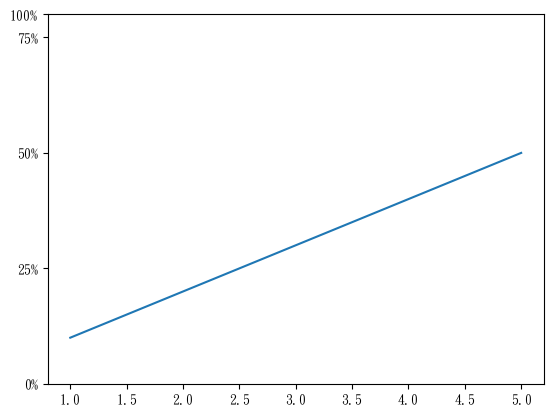

In [4]:
import matplotlib.pyplot as plt

# 假设有一些数据
y_values = [10, 20, 30, 40, 50]
x_values = [1, 2, 3, 4, 5]

# 绘制图形
plt.plot(x_values, y_values)

# 自定义y轴刻度
custom_ticks = [0, 25, 50, 75, 80]  # 自定义刻度位置
custom_labels = ['0%', '25%', '50%', '75%', '100%']  # 自定义刻度标签

plt.yticks(custom_ticks, custom_labels)

# 显示图形
plt.show()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


[(2438, 147134, 2023, 6, 22, '所謂的孝順就是這樣吧？'), (2524, 162925, 2023, 6, 21, '這女人真的蠻瘋的。'), (3695, 257713, 2023, 6, 20, '這是一場唐唐正正的對決。'), (2874, 176354, 2023, 6, 19, '原來一直以來都是我錯了？'), (1661, 124882, 2023, 6, 16, '為什麼可以這麼吵？'), (3406, 203204, 2023, 6, 15, '這種事問我就對了。'), (2687, 199138, 2023, 6, 12, '看了這些人覺得我好像蠻正常的。'), (2876, 235313, 2023, 6, 9, '這幾個真的有夠惡劣。'), (2234, 101894, 2023, 6, 8, '又被黃標，我決定改當健身教練。'), (2598, 185581, 2023, 6, 6, '這些對我來說都是雕蟲小技。'), (3656, 314342, 2023, 6, 3, '能打架就不要吵架。'), (2642, 169699, 2023, 6, 2, '難道年紀到了就一定會這樣？'), (5078, 311765, 2023, 5, 25, '老人最幽默的一次？'), (6070, 343785, 2023, 5, 20, '有時候真的不懂這些人在想什麼。'), (2870, 231394, 2023, 5, 14, '其實你們完全錯看我了。'), (3430, 221907, 2023, 5, 12, '我一看就知道問題在哪。'), (4338, 267934, 2023, 5, 9, '幕後黑手原來是他？'), (5137, 237993, 2023, 5, 8, '一日為師，終生為父。'), (1963, 139071, 2023, 5, 7, '最強AI：我覺得館長XXX了'), (2583, 160224, 2023, 5, 6, '飲料店招牌被拆了？'), (3022, 159194, 2023, 4, 27, '對館長真情流露的告白。'), (4698, 232017, 2023, 4, 25, '館長其實是無辜的？'), (5398, 269581, 2023, 4, 24, '我給館長最中肯的

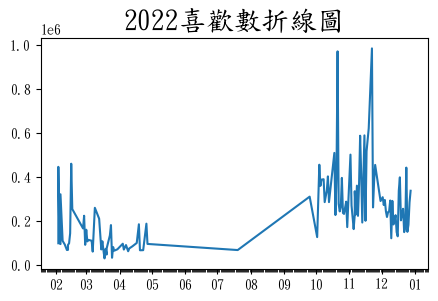

[(2438, 147134, 2023, 6, 22, '所謂的孝順就是這樣吧？'), (2524, 162925, 2023, 6, 21, '這女人真的蠻瘋的。'), (3695, 257713, 2023, 6, 20, '這是一場唐唐正正的對決。'), (2874, 176354, 2023, 6, 19, '原來一直以來都是我錯了？'), (1661, 124882, 2023, 6, 16, '為什麼可以這麼吵？'), (3406, 203204, 2023, 6, 15, '這種事問我就對了。'), (2687, 199138, 2023, 6, 12, '看了這些人覺得我好像蠻正常的。'), (2876, 235313, 2023, 6, 9, '這幾個真的有夠惡劣。'), (2234, 101894, 2023, 6, 8, '又被黃標，我決定改當健身教練。'), (2598, 185581, 2023, 6, 6, '這些對我來說都是雕蟲小技。'), (3656, 314342, 2023, 6, 3, '能打架就不要吵架。'), (2642, 169699, 2023, 6, 2, '難道年紀到了就一定會這樣？'), (5078, 311765, 2023, 5, 25, '老人最幽默的一次？'), (6070, 343785, 2023, 5, 20, '有時候真的不懂這些人在想什麼。'), (2870, 231394, 2023, 5, 14, '其實你們完全錯看我了。'), (3430, 221907, 2023, 5, 12, '我一看就知道問題在哪。'), (4338, 267934, 2023, 5, 9, '幕後黑手原來是他？'), (5137, 237993, 2023, 5, 8, '一日為師，終生為父。'), (1963, 139071, 2023, 5, 7, '最強AI：我覺得館長XXX了'), (2583, 160224, 2023, 5, 6, '飲料店招牌被拆了？'), (3022, 159194, 2023, 4, 27, '對館長真情流露的告白。'), (4698, 232017, 2023, 4, 25, '館長其實是無辜的？'), (5398, 269581, 2023, 4, 24, '我給館長最中肯的

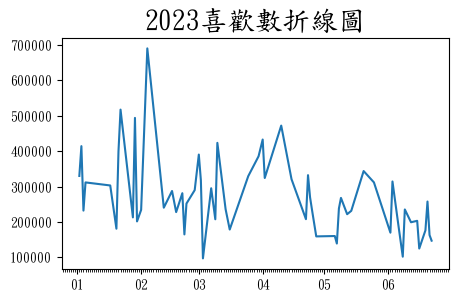

127.0.0.1 - - [23/Jun/2023 14:39:40] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [23/Jun/2023 14:39:40] "GET /static/img12/a1.png HTTP/1.1" 200 -
127.0.0.1 - - [23/Jun/2023 14:39:40] "GET /static/img12/a2.png HTTP/1.1" 200 -


pathl [['img12', 'a1.png'], ['img12', 'a2.png']]
n1 img12


In [5]:
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
import pyodbc,time,os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from flask import Flask, render_template,request
app = Flask(__name__, template_folder=r"C:\Users\h7236\OneDrive\桌面\f_templates")
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
@app.route('/')
def index():
    a = "SELECT * FROM vdata"
    results = conn.execute(a)
    videos = results.fetchall()
    print(videos)
    print(videos[0][2],videos[len(videos)-1][2])
    print(range(int(videos[0][2]),int(videos[len(videos)-1][2]+1)))
    ll=[]
    for i in range(videos[len(videos)-1][2]+1,videos[0][2]+1):
        print(i)
        l=[]
        for j in videos:
            if j[2]==i:
                l.append(j)
        ll.append(l)
    n1=1
    print('n1n1',n1)
    while(True):
        if os.path.exists(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}'):
            n1+=1
            print('n1',n1)
        else:
            os.mkdir(fr'C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}')
            print('aaaaaaaa')
            break
    nn=0
    print('n1',nn)
    pathl=[]
    for l in ll:
        print(l)
        font_path = r'C:\Windows\Fonts\kaiu.ttf'
        plt.rcParams['font.sans-serif'] = ['DFKai-SB']
        plt.rcParams['axes.unicode_minus'] = False
        months = mdates.MonthLocator()
        days = mdates.DayLocator()
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.xaxis.set_major_locator(months)
        ax.xaxis.set_minor_locator(days)
        timeFmt = mdates.DateFormatter('%m')
        ax.xaxis.set_major_formatter(timeFmt)
        print('tj2',type(j[2]))
        dates=[datetime.date(j[2],j[3],j[4]) for j in l]
        watchs=[j[1] for j in l]
        plt.plot(dates,watchs)
        plt.title(f"{l[0][2]}喜歡數折線圖", fontsize=20)
        nn+=1
        pathl.append([f"img{n1}",f"a{nn}.png"])
        plt.savefig(fr"C:\Users\h7236\OneDrive\桌面\f_templates\static\img{n1}\a{nn}.png")
        plt.show()
    n1=f'img{n1}'
    print('pathl',pathl)
    print('n1',n1)
    return render_template('ff.html',**locals())
app.run()

In [9]:
print(type(3))

<class 'int'>


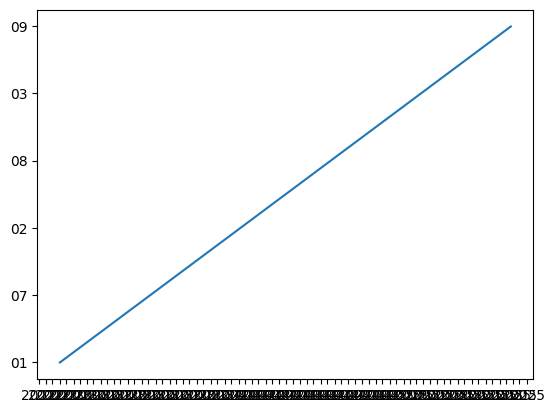

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# 創建圖片和子圖對象
fig, ax = plt.subplots()

# 設定 x 軸刻度定位器
locator = mdates.AutoDateLocator(minticks=1000) # 最大刻度數量為 10
ax.xaxis.set_major_locator(locator)

# 設定 x 軸刻度格式
timeFmt = mdates.DateFormatter('%m')
ax.yaxis.set_major_formatter(timeFmt)

# 假設這是您的日期和數據
dates = [datetime.date(2023, 1, 1) + datetime.timedelta(days=i) for i in range(1000)]
values = range(1000)

# 繪製折線圖
plt.plot(dates, values)
plt.show()

In [20]:
import os
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
import pyodbc,time,os
from flask import Flask, render_template,request
app = Flask(__name__, template_folder=r"C:\Users\h7236\OneDrive\桌面\f_templates")
@app.route('/gallery')
def gallery():
    # 資料夾路徑
    folder_path = r'C:\Users\h7236\OneDrive\桌面\f_templates\img18'

    # 獲取資料夾中所有圖片的檔案名稱
    image_files = os.listdir(folder_path)
    
    return render_template('gallery.html', image_files=image_files)
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [22/Jun/2023 16:24:10] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [22/Jun/2023 16:24:21] "GET /gallery HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2023 16:24:22] "GET /static/a3.png HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2023 16:24:22] "GET /static/a1.png HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2023 16:24:22] "GET /static/a2.png HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2023 16:24:22] "GET /static/a5.png HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2023 16:24:22] "GET /static/a4.png HTTP/1.1" 200 -


n1 0


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [21/Jun/2023 23:55:03] "GET / HTTP/1.1" 404 -


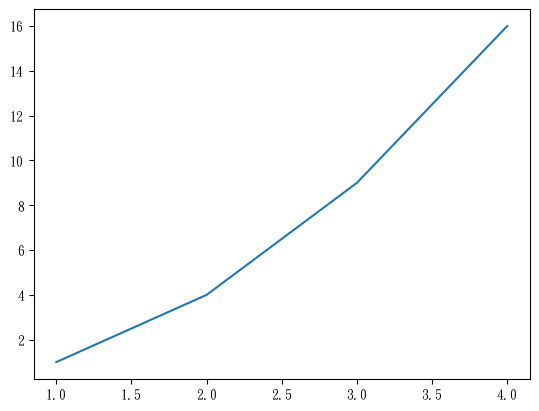

[2023-06-21 23:55:11,066] ERROR in app: Exception on /plot [GET]
Traceback (most recent call last):
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 2190, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1486, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1484, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\h7236\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1469, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

<Figure size 640x480 with 0 Axes>

In [95]:
import matplotlib.pyplot as plt
app = Flask(__name__, template_folder=r"C:\Users\h7236\OneDrive\桌面\f_templates")
@app.route('/plot')
def plot():
    # 生成圖形
    plt.plot([1, 2, 3, 4], [1, 4, 9, 16])
    plt.show()
    # 保存圖片文件
    plt.savefig('static/plot.png')  # 將圖片保存為靜態文件夾中的 plot.png

    # 關閉圖形
    plt.close()

    return 'Plot generated and saved'
app.run()

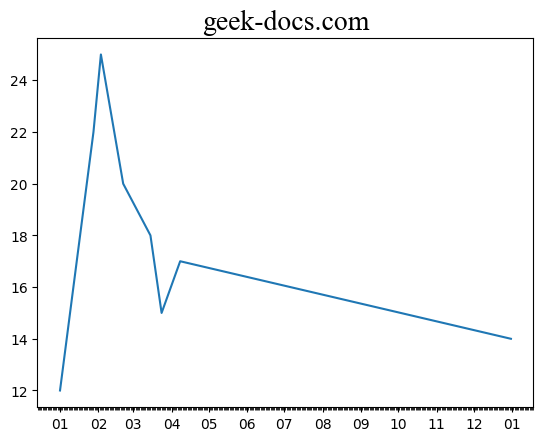

In [72]:
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates

# 获取每月数据
months = mdates.MonthLocator()
# 获取每日数据
days = mdates.DayLocator()

events = [datetime.date(2015,1,1), datetime.date(2015,1,28), datetime.date(2015,2,3),
          datetime.date(2015,2,21),datetime.date(2015,3,15),datetime.date(2015,3,24),
          datetime.date(2015,4,8),datetime.date(2015,12,31)]
readings = [12, 22, 25, 20, 18, 15, 17, 14]
fig, ax = plt.subplots()
plt.plot(events, readings)
# 设定主/次刻度
ax.xaxis.set_major_locator(months)
ax.xaxis.set_minor_locator(days)
# 设定格式
timeFmt = mdates.DateFormatter('%m')
ax.xaxis.set_major_formatter(timeFmt)
plt.title("geek-docs.com", fontsize=20, fontname="Times New Roman")

plt.show()

In [12]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from flask import Flask, render_template,request
from selenium.webdriver.common.action_chains import ActionChains
from datetime import date,datetime
import pyodbc,time
from selenium.webdriver.chrome.options import Options
chrome_options = Options()
chrome_options.add_argument("--memory-model=high")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()),options=chrome_options)
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
def get_vdata(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        title nvarchar(100)
    )'''#messages int,
    conn.execute(a)
    conn.commit() 
    for url in urls:
        get_time()
        url=url[0]
        driver.get(url)
        time.sleep(1.2)

        a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        else:
            likes=int(a.text)
        
        driver.find_element(By.XPATH,'//*[@id="expand"]').click()
        time.sleep(0.3)

        b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        watchs=int(''.join((b.text[5:len(b.text)-1]).split(',')))

        c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        t=c.text
        if t[0:5]=='首播日期：':
            t=t[5:len(t)]
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
            '''
        driver.find_element(By.XPATH,'//*[@id="collapse"]').click()
        time.sleep(0.3)
        for i in range(3):
            driver.find_element(By.XPATH,'/html').send_keys(Keys.DOWN)
        time.sleep(0.3)
        try:
            d=driver.find_element(By.XPATH,'//*[@id="count"]/yt-formatted-string/span[1]')
            messages=int(''.join((d.text).split(',')))
        except:
            messages=0
            '''
        e=driver.find_element(By.XPATH,'//*[@id="title"]/h1/yt-formatted-string')
        title=e.text

        print(f'{likes},{watchs},{year},{month},{day},{title}')#{messages} #{title}
        a=f'''insert into vdata (likes, watchs, year, month, day, title) values
                ({likes},{watchs},{year},{month},{day},?)
        '''#,{messages}
        conn.execute(a,title)
        conn.commit() 
def get_time():
    ti=datetime.now()
    print('時間:',ti.hour,ti.minute,ti.second)
a = "SELECT * FROM tdata"
results = conn.execute(a)
videos = results.fetchall()
videos=[('https://www.youtube.com/watch?v=fsvjcf5Q5ZM',)]
get_vdata(videos)


時間: 14 58 45
6003,771444,2019,6,27,【巨人人物傳】還敢下來啊? 萊納(Reinertin' A Fool)


In [ ]:
def get_vdata(urls):
    get_time()
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        messages int,
    )'''
    conn.execute(a)
    conn.commit() 
    for url in urls:
        get_time()
        driver.get(url)
        time.sleep(1)

        a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        else:
            likes=int(a.text)
        
        driver.find_element(By.XPATH,'//*[@id="expand"]').click()
        time.sleep(0.5)

        b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        watchs=int(''.join((b.text[5:len(b.text)-1]).split(',')))

        c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        t=c.text
        if t[0:5]=='首播日期:':
            t=t[5:len(t)]
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
            
        driver.find_element(By.XPATH,'//*[@id="collapse"]').click()
        time.sleep(0.5)
        for i in range(10):
            driver.find_element(By.XPATH,'/html').send_keys(Keys.DOWN)
        time.sleep(1)
        try:
            d=driver.find_element(By.XPATH,'//*[@id="count"]/yt-formatted-string/span[1]')
            messages=int(''.join((d.text).split(',')))
        except:
            messages=0
        print(f'{likes},{watchs},{year},{month},{day},{messages}')
        a=f'''insert into vdata (likes, watchs, year, month, day, messages) values
                ({likes},{watchs},{year},{month},{day},{messages})
        '''
        conn.execute(a)
        conn.commit() 

In [7]:
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
conn.close()

In [80]:
print('首播日期：2022'[0:5])

首播日期：


In [64]:
def get_time():
    ti=datetime.now()
    print('時間:',ti.hour,ti.minute,ti.second)
for i in range(100):
    time.sleep(1)
    get_time()

時間: 21 56 33
時間: 21 56 34
時間: 21 56 35
時間: 21 56 36
時間: 21 56 37
時間: 21 56 38
時間: 21 56 39
時間: 21 56 40
時間: 21 56 41
時間: 21 56 42
時間: 21 56 43
時間: 21 56 44
時間: 21 56 45


KeyboardInterrupt: 

In [35]:
def get_cdata(x):
    a='''
        DROP TABLE IF EXISTS cdata;
        CREATE TABLE cdata (
            cheadsrc NVARCHAR(300),
            cname NVARCHAR(100),
            csub NVARCHAR(100),
            curl NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    def channels(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        img = driver.find_elements(By.XPATH, '//*[@id="img"]')
        uptimes = 10 
        times = 0
        actions = ActionChains(driver)
        while times < uptimes:
            actions.send_keys(Keys.PAGE_DOWN)
            actions.perform()
            times += 1
            src = [i.get_attribute('src') for i in img]
            img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
            img_src = img_element.get_attribute('src')
            if img_src is None:
                break
        return src

    def names(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        container = driver.find_elements(By.XPATH, '//*[@id="text"]')
        nam = [j.text for j in container]
        return nam

    def num(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
        num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
        return num2

    def web(x):
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
        web2=[l.get_attribute('href') for l in web1]
        return web2
    
    a1=channels(x)
    b1=names(x)
    c1=num(x)
    d1=web(x)
    l=min(len(a1),len(b1),len(c1),len(d1))
    if l>16:
        l=16
    for i in range(l):
        a = f'''INSERT INTO cdata (cheadsrc,cname,csub,curl) VALUES
                ('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
        '''
        conn.execute(a)
        conn.commit() 
    conn.close()


a = input()
get_cdata(a)

In [49]:
from time import sleep
import csv
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyodbc
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
channels_video=['https://www.youtube.com/@fourteenthjudicialcircuito1005/videos']#給定網址，可改

conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;')

def get_tdate(x):
    driver.get(f'{x}/videos')
    a='''
        DROP TABLE IF EXISTS tdata;
        CREATE TABLE tdata (
            videos NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()

    aa=driver.find_element(By.XPATH,'//*[@id="videos-count"]/span[1]')

    cc=int(aa.text)
    dd=round(cc/3)
    uptimes =int(dd)
    times = 0
    actions = ActionChains(driver)
    while times < uptimes:
        actions.send_keys(Keys.PAGE_DOWN)
        actions.perform()
        times += 1
        img_element = driver.find_element(By.XPATH, '//*[@id="video-title-link"]')
        img_src = img_element.get_attribute('href')
        if img_src is None:
            break
    po1=driver.find_elements(By.XPATH,'//*[@id="video-title-link"]')
    po2 = [j.get_attribute('href') for j in po1]
    for i in range(len(po2)):
        a = f'''INSERT INTO tdata (videos) VALUES
                ('{po2[i]}')
        '''
        conn.execute(a)
        conn.commit() 
    conn.close()
get_tdate('https://www.youtube.com/@cryochamberlabel')


In [ ]:
#old
def get_cdata(x):
    a='''
        DROP TABLE IF EXISTS cdata;
        CREATE TABLE cdata (
            cheadsrc NVARCHAR(300),
            cname NVARCHAR(100),
            csub NVARCHAR(100),
            curl NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    url=f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D'
    def channels(x):
        #print('a')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        img = driver.find_elements(By.XPATH, '//*[@id="img"]')
        uptimes = 10 
        times = 0
        actions = ActionChains(driver)
        while times < uptimes:
            actions.send_keys(Keys.PAGE_DOWN)
            actions.perform()
            times += 1
            src = [i.get_attribute('src') for i in img]
            img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
            img_src = img_element.get_attribute('src')
            if img_src is None:
                break
        return src

    def names(x):
        #print('b')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        container = driver.find_elements(By.XPATH, '//*[@id="text"]')
        nam = [j.text for j in container]
        return nam

    def num(x):
        #print('c')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
        num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
        return num2

    def web(x):
        #print('d')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        time.sleep(2)
        web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
        web2=[l.get_attribute('href') for l in web1]
        return web2
    
    driver.get(url)
    time.sleep(2)
    a1=channels(x)
    time.sleep(2)
    b1=names(x)
    time.sleep(2)
    c1=num(x)
    time.sleep(2)
    d1=web(x)
    l=min(len(a1),len(b1),len(c1),len(d1))
    if l>16:
        l=16
    for i in range(l):
        a = f'''INSERT INTO cdata (cheadsrc,cname,csub,curl) VALUES
                ('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
        '''
        conn.execute(a)
        conn.commit() 

In [18]:
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
a = "SELECT * FROM cdata"
results = conn.execute(a)
data = results.fetchall() 
print(data)

[('https://yt3.googleusercontent.com/ytc/AGIKgqNiQnRJMW78Qu1NWPk7gP7PZ0tFgTxYq2lMZSFvJQ=s176-c-k-c0x00ffffff-no-rj-mo', 'Joeman', '253萬位訂閱者', 'https://www.youtube.com/@joeman'), ('https://yt3.googleusercontent.com/ytc/AGIKgqMsikFgulRLwXmbH0CAs1PZQ3pO8SUTf-p3-UfiOg=s176-c-k-c0x00ffffff-no-rj-mo', 'Joemen Crazo', '6430位訂閱者', 'https://www.youtube.com/@joemencrazo51972'), ('https://yt3.ggpht.com/qL9afgdBKRRyiL-ljInW5DgtCNBLIK36bcAGYvoXjMeKgIvzZ2OiMMGa1I_r7MP2O0sGwLN7=s176-c-k-c0x00ffffff-no-rj-mo', 'DJ JoeMen', '324位訂閱者', 'https://www.youtube.com/@djjoemen9994'), ('https://yt3.googleusercontent.com/ytc/AGIKgqNGVUv6M6lxmFNksFdW3mlw2vuqYPKgs0H5diPE=s176-c-k-c0x00ffffff-no-rj-mo', 'Joemen Official', '8位訂閱者', 'https://www.youtube.com/@Mylque-ing'), ('https://yt3.ggpht.com/JMOZYqjprhmwXbko-yrzOkPu1Oc1m5rhfnEiMbTbwqozRx96FMxC2XGIdbZTL4E6jIyW5yfGzw=s176-c-k-c0x00ffffff-no-rj-mo', 'Mylque', '4.66萬位訂閱者', 'https://www.youtube.com/@joemenofficial'), ('https://yt3.googleusercontent.com/ytc/AGIKgqObLBq

In [16]:
from time import sleep
import csv
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyodbc

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;')

def get_cdate(x):
    a='''
        DROP TABLE IF EXISTS cdata;
        CREATE TABLE cdata (
            cheadsrc NVARCHAR(300),
            cname NVARCHAR(100),
            csub NVARCHAR(100),
            curl NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit()
    url=f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D'
    def channels(x):
        #print('a')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        sleep(2)
        img = driver.find_elements(By.XPATH, '//*[@id="img"]')
        uptimes = 10 
        times = 0
        actions = ActionChains(driver)
        while times < uptimes:
            actions.send_keys(Keys.PAGE_DOWN)
            actions.perform()
            times += 1
            src = [i.get_attribute('src') for i in img]
            img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
            img_src = img_element.get_attribute('src')
            if img_src is None:
                break
        return src

    def names(x):
        #print('b')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        sleep(2)
        container = driver.find_elements(By.XPATH, '//*[@id="text"]')
        nam = [j.text for j in container]
        return nam

    def num(x):
        #print('c')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        sleep(2)
        num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
        num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
        return num2

    def web(x):
        #print('d')
        driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
        sleep(2)
        web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
        web2=[l.get_attribute('href') for l in web1]
        return web2
    
    driver.get(url)
    sleep(2)
    a1=channels(x)
    sleep(2)
    b1=names(x)
    sleep(2)
    c1=num(x)
    sleep(2)
    d1=web(x)
    #print('ttttttttttt',a1,b1,c1,d1)
    l=min(len(a1),len(b1),len(c1),len(d1))
    if l>18:
        l=18
    for i in range(l):
        a = f'''INSERT INTO cdata (cheadsrc,cname,csub,curl) VALUES
                ('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
        '''
        conn.execute(a)
        conn.commit() 

    conn.close()


a = input()

get_cdate(a)


In [ ]:
from time import sleep
import csv
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyodbc
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.find_element(By.XPATH,'//*[@id="thumbnail"]')

In [38]:
import pyodbc
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
a = '''
    DROP TABLE IF EXISTS testd 
    CREATE TABLE testd (
        src nvarchar(300),
        an nvarchar(300)
    )
'''

conn.execute(a)
conn.commit() 
src='https://yt3.googleusercontent.com/ytc/AGIKgqOAz0W95mydHNG9nMfnY9J1pytsWGCI5H0H1kfc=s176-c-k-c0x00ffffff-no-rj-mo'
an='adelk.,ll/'

a=f'''insert into testd (src,an) values
        ('{src}','{an}')
    '''

conn.execute(a)
conn.commit() 
conn.close()


In [26]:
import pyodbc
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )
conn.close()

In [20]:
print(len('https://yt3.googleusercontent.com/ytc/AGIKgqOAz0W95mydHNG9nMfnY9J1pytsWGCI5H0H1kfc=s176-c-k-c0x00ffffff-no-rj-mo'))

112


In [39]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time,pyodbc
from datetime import date
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
v_url=['https://www.youtube.com/watch?v=GTgik_4toIo','https://youtu.be/XqZsoesa55w','https://www.youtube.com/watch?v=nG-MN4y28Iw','https://youtu.be/zPhUO4zqDQo','https://youtu.be/ix6ETiz1R4Y','https://youtu.be/L-5bt0Njh3o','https://youtu.be/oqEvOHspv2U']

conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;'
    )

def get_vdata(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
        messages int,
    )'''
    conn.execute(a)
    conn.commit() 
    for url in urls:
        driver.get(url)
        time.sleep(1)
        a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')#like
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        else:
            likes=int(a.text)
        driver.find_element(By.XPATH,'//*[@id="expand"]').click()
        time.sleep(1)
        b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        watchs=int(''.join((b.text[5:len(b.text)-1]).split(',')))
        c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        t=c.text
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
        driver.find_element(By.XPATH,'//*[@id="collapse"]').click()
        time.sleep(1)
        for i in range(10):
            driver.find_element(By.XPATH,'/html').send_keys(Keys.DOWN)
        time.sleep(2)
        try:
            d=driver.find_element(By.XPATH,'//*[@id="count"]/yt-formatted-string/span[1]')
            messages=int(''.join((d.text).split(',')))
        except:
            messages=0
        #print(f'{likes},{watchs},{year},{month},{day},{messages}')
        a=f'''insert into vdata (likes, watchs, year, month, day, messages) values
                ({likes},{watchs},{year},{month},{day},{messages})
        '''
        conn.execute(a)
        conn.commit() 
    conn.close()
    
get_vdata(v_url)

ValueError: invalid literal for int() with base 10: '首播日期：2023'

In [ ]:
#備份old get_vdata
def get_vdate(urls):
    a = '''
        DROP TABLE IF EXISTS vdata 
        CREATE TABLE vdata (
        likes int,
        watchs bigint,
        year int,
        month int,
        day int,
    )'''
    conn.execute(a)
    conn.commit() 
    for url in urls:
        driver.get(url)
        time.sleep(1)
        a=driver.find_element(By.XPATH,'//*[@id="segmented-like-button"]/ytd-toggle-button-renderer/yt-button-shape/button/div[2]/span')#like
        if a.text[len(a.text)-1]=='萬':
            likes=int(float(a.text[0:len(a.text)-1])*10000)
        else:
            likes=int(a.text)
        #print(likes)
        driver.find_element(By.XPATH,'//*[@id="expand"]').click()
        time.sleep(1)
        b=driver.find_element(By.XPATH,'//*[@id="info"]/span[1]')
        watchs=int(''.join((b.text[5:len(b.text)-1]).split(',')))
        #print(watchs)
        c=driver.find_element(By.XPATH,'//*[@id="info"]/span[3]')
        t=c.text
        if t[0]=='於':
            t = str(date.today())
            year=int(t[0:4])
            month=int(t[5:7])
            day=int(t[8:10])
        else:
            for i in range(len(t)):
                if t[i]=='年':
                    a1=i
                if t[i]=='月':
                    a2=i
            year=int(t[0:a1])
            month=int(t[a1+1:a2])
            day=int(t[a2+1:len(t)-1])
        a=f'''insert into vdata (likes, watchs, year, month, day) values
                ({likes},{watchs},{year},{month},{day})
        '''
        conn.execute(a)
        conn.commit() 
    conn.close()

In [12]:
from time import sleep
import csv
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import pyodbc

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=DESKTOP-BAKUBIS\MSSQLSERVER01;'
    'Database=testdb;'
    'Trusted_Connection=yes;')

def channels(x):
    print('a')
    driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
    sleep(2)
    img = driver.find_elements(By.XPATH, '//*[@id="img"]')
    uptimes = 10 
    times = 0
    actions = ActionChains(driver)
    while times < uptimes:
        actions.send_keys(Keys.PAGE_DOWN)
        actions.perform()
        times += 1
        src = [i.get_attribute('src') for i in img]
        img_element = driver.find_element(By.XPATH, '//*[@id="img"]')
        img_src = img_element.get_attribute('src')
        if img_src is None:
            break
    return src

def names(x):
    print('b')
    driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
    sleep(2)
    container = driver.find_elements(By.XPATH, '//*[@id="text"]')
    nam = [j.text for j in container]
    return nam

def num(x):
    print('c')
    driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
    sleep(2)
    num1 = driver.find_elements(By.XPATH, '//*[@id="video-count"]')
    num2= [j.text if j.text != '' else '0位訂閱者' for j in num1]
    return num2

def web(x):
    print('d')
    driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
    sleep(2)
    web1=driver.find_elements(By.XPATH,'//*[@id="avatar-section"]/a')
    web2=[l.get_attribute('href') for l in web1]
    return web2

def get_rdate(urls2):
    a='''
        DROP TABLE IF EXISTS rdata;
        CREATE TABLE rdata (
            channels NVARCHAR(300),
            names NVARCHAR(100),
            num NVARCHAR(100),
            web NVARCHAR(300)
        )
    '''
    conn.execute(a)
    conn.commit() 

    for url in urls2:
        driver.get(url)
        sleep(2)
        a1=channels(x)
        sleep(2)
        b1=names(x)
        sleep(2)
        c1=num(x)
        sleep(2)
        d1=web(x)
        print('ttttttttttt',a1,b1,c1,d1)
        l=min(len(a1),len(b1),len(c1),len(d1))
        for i in range(l):
            a = f'''INSERT INTO rdata (channels,names,num,web) VALUES
                    ('{a1[i]}', '{b1[i]}', '{c1[i]}','{d1[i]}')
            '''
            conn.execute(a)
            conn.commit() 

    conn.close()


x = input()
b = [f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D']
get_rdate(b)

channels(x)#7一個群組
names(x)#20一個群組
num(x)#20一個群組
web(x)#20一個群組

a
b
c
d
ttttttttttt ['https://yt3.ggpht.com/uaUo_GiEPqj5q-0JDUNJ5uqdHHZdkrpADtRgu30GwkBh_JKqzeLg5s6Xm2oOT8RBYs8wU5zKRw=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/h_1BkV-qyADx-NSNtfek1whfGb-7eQSu08LtAN01cbjLcivhGxTLF6ZdU9QRU8QsOOS3ar5kbw=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqNM3bIHNvZqz4LNypSSjsv0SsX1qkQtk94uKlCB=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/o7I5ohTw_D4ooTxQUbjNrkAQ2ssfwHXqheimSNtYIBngNaPcM593Ncpre93ByYbT7fZbeHLKnbs=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/xy_SgJipjHBpJ9sbBRHpcN-N7vmMeKN1k5gwCtQRuTAEL0Brv5WFdl1lczhGo2-v178tV2fMaQ=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/K2ke-n-3kXKvwzJObkGEfVEZpi97oGqn8nImNlFbH9o0qpK8-jq2TZhsB537lLbkkqzUXNXI9w=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqOAz0W95mydHNG9nMfnY9J1pytsWGCI5H0H1kfc=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqPnbgSrSO6Eku2-bGxucc6dSRav4UH6QPks8N7jQA=s176-c-k-c

['https://www.youtube.com/@Notorious_3cm',
 'https://www.youtube.com/@GenghisKhan_3cm',
 'https://www.youtube.com/@user-ne2ox4lm2n',
 'https://www.youtube.com/@user-yt2cs7qq4k',
 'https://www.youtube.com/@BAOBAOXD',
 'https://www.youtube.com/@ShanQiang1208',
 'https://www.youtube.com/@user-im8gd9ch6t',
 'https://www.youtube.com/@user-jp2oh2wl1r',
 'https://www.youtube.com/@user-ww3vo3dh4l',
 'https://www.youtube.com/@tyc8360',
 'https://www.youtube.com/@user-vr8rj2mn7c',
 'https://www.youtube.com/@musclemoney',
 'https://www.youtube.com/@KantyouV',
 'https://www.youtube.com/@user-qt2ux7br8y',
 'https://www.youtube.com/@user-lx8vy7ps7m',
 'https://www.youtube.com/@user-hy4bz8nn7t',
 'https://www.youtube.com/@funnycatmeow',
 'https://www.youtube.com/@user-sw1pu1ud1k',
 'https://www.youtube.com/@GuanZhangYuXianSheng',
 'https://www.youtube.com/@CURATORTOME']

In [11]:
l=min(2,2,3)
print(l)

2


In [33]:
from datetime import date

# 取得今天的日期
t = str(date.today())
year=int(t[0:4])
month=int(t[5:7])
day=int(t[8:10])

# 輸出今天的日期

print(year,month,day)

2023 6 19


In [19]:
from time import sleep
import csv
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
from bs4 import BeautifulSoup
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
q=[]
x=input()
b=f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D'
#d=driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
def channels(x):
    print('a')
    driver.get(f'https://m.youtube.com/results?search_query={x}&sp=EgIQAg%253D%253D')
    sleep(2)
    img=driver.find_elements(By.XPATH,'//*[@id="img"]')
        #src=[i.get_attribute('src') for i in img]
    max_scroll_times = 10 
    scroll_times = 0
    actions = ActionChains(driver)
    while scroll_times < max_scroll_times:
      actions.send_keys(Keys.PAGE_DOWN)
      actions.perform()
      scroll_times += 1
      src=[i.get_attribute('src') for i in img]
      img_element = driver.find_element(By.XPATH,'//*[@id="img"]')
      img_src = img_element.get_attribute('src')
      if img_src is None:
          break
   # if src=='None':  
    #  actions = ActionChains(driver)
     ##actions.perform() 
    #else:
     # src=[i.get_attribute('src') for i in img]
    #actions.send_keys(Keys.PAGE_DOWN)
    #actions.perform() 
    #src=[i.get_attribute('src') for i in img]
    #w=get_attribute('src')
      #  if i.get_attribute('src')=='None':
       #     driver.find_element(By.XPATH,'/html').send_keys(Keys.ARROW_DOWN)
      ##     src=[i.get_attribute('src')]
    print(src)
    #//*[@id="text-container"]
channels(x)#7一個群組

a
['https://yt3.googleusercontent.com/ytc/AGIKgqNiQnRJMW78Qu1NWPk7gP7PZ0tFgTxYq2lMZSFvJQ=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/qL9afgdBKRRyiL-ljInW5DgtCNBLIK36bcAGYvoXjMeKgIvzZ2OiMMGa1I_r7MP2O0sGwLN7=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqNnBG3Ym3AuJFMDmyEVvcg8P_NHpSAa3KGdIJm-gw=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqORQgmHx8Azzj6WZYq9jnSlGXnW276ynPWTwpXO=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqNR7dvPJLzmEOXfDmHnlKqbulYQKaWqXFv-EhBS=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/WsUtWOM8maqSsAfoY2WYnsj3BhOn8AHsA1cItMpr8jKsS7hfiHY5Pfjflvuqn7vdwFCXZx6ThQ=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleusercontent.com/ytc/AGIKgqNob--RnrNeQ81El_TA1AeyKqcebbAhf1zIxGLNvVE=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.ggpht.com/GL4kvqDup-NVTqMF2oaY3qxsBkNWHqAWeynhVTq8er2Rd5sBzs-5sVWOnqcN9UXOrtux6cnXeQ=s176-c-k-c0x00ffffff-no-rj-mo', 'https://yt3.googleuse